# Unit Graph Test - For transit-visualization only

## Section 1. Config

In [41]:

# Configuration
TARGET = "Kepler-186"  # Change this to your target
MISSION = "Kepler"  # or "TESS"
SIGMA_CLIP = 5.0
DOWNLOAD_ALL = True  # Set to True to download all available files and stitch them

USE_TLS = False
VERBOSE = True
REFINE_DURATION = True
SYSTEMATICS_CORRECTION = "off" # off, cbv, reg, both
INCLUDE_ML_CUTOUTS = False
ACCEPTANCE_FACTOR_FOR_SHORT_MOVES = 0.85

## Section 2. Imports

In [42]:
import sys

import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt

sys.path.insert(0, '../src')

from download_and_clean import download_and_clean_lightcurve

## Section 3. Downloading data

In [43]:
print(f"Searching for {TARGET} in {MISSION} mission...")
search_result = lk.search_lightcurve(TARGET, mission=MISSION)
print(f"Found {len(search_result)} light curve files")

Searching for Kepler-186 in Kepler mission...
Found 44 light curve files


In [44]:
lc = download_and_clean_lightcurve(TARGET, MISSION, SIGMA_CLIP, all=DOWNLOAD_ALL, verbose=VERBOSE)

Downloaded 1132328 data points.


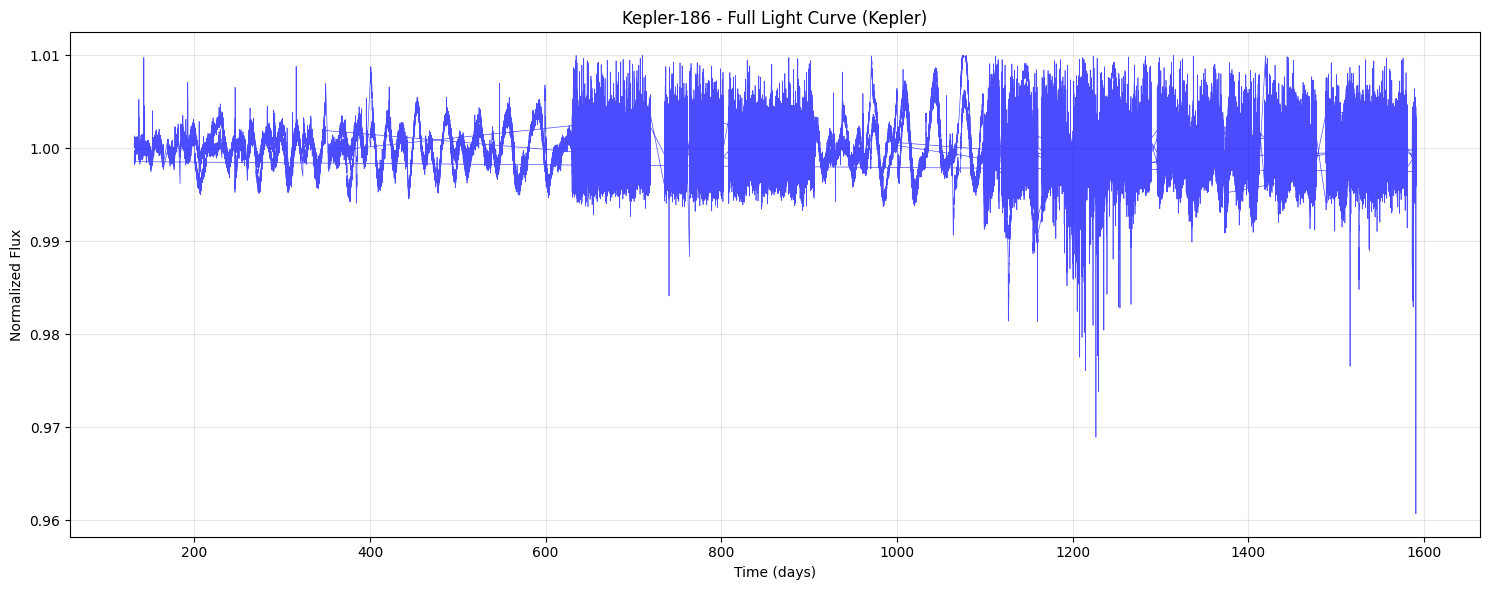

In [45]:
# Plot the full light curve
plt.figure(figsize=(15, 6))
plt.plot(lc.time.value, lc.flux.value, 'b-', alpha=0.7, linewidth=0.5)
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
plt.title(f'{TARGET} - Full Light Curve ({MISSION})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


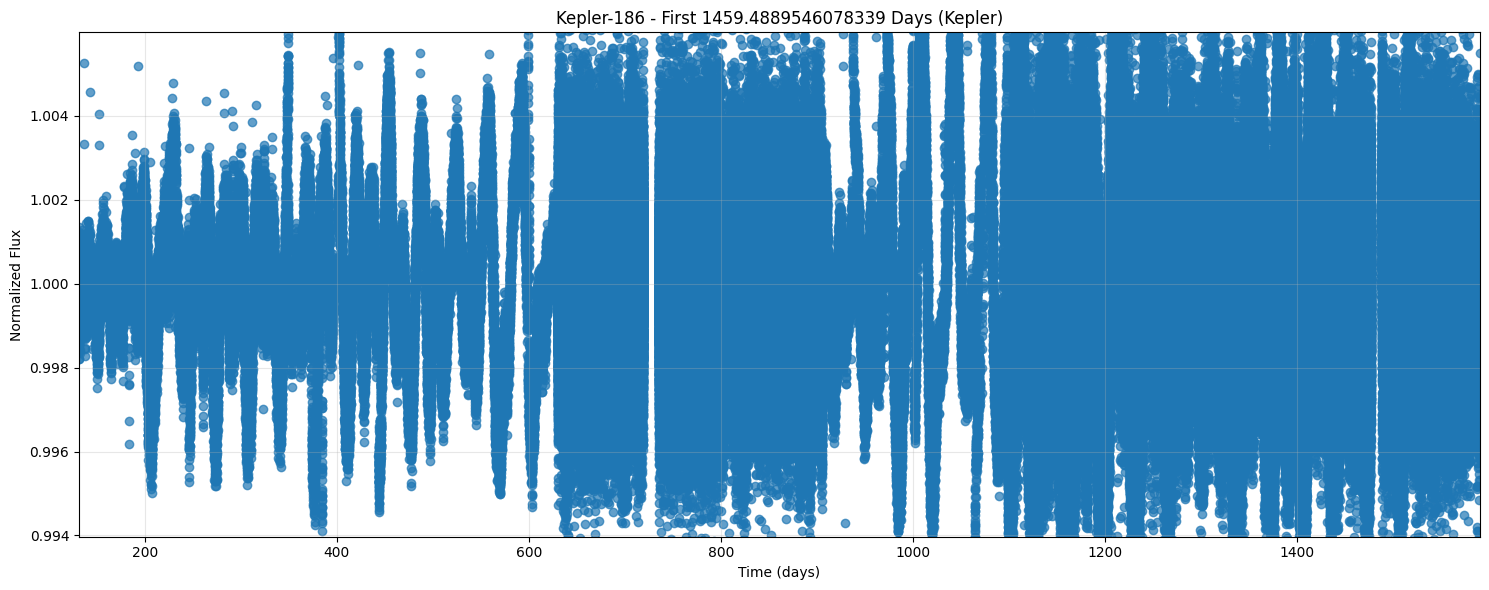

In [46]:
WINDOW_PERIOD_DAYS = 65535  # Window period in days for the zoomed-in plot

# Plot the full light curve
# Plot the first WINDOW_PERIOD_DAYS days of the light curve
plt.figure(figsize=(15, 6))
WINDOW_PERIOD_DAYS = min(WINDOW_PERIOD_DAYS, lc.time.value[-1] - lc.time.value[0])  # Ensure we don't exceed the available data
mask = (lc.time.value <= lc.time.value[0] + WINDOW_PERIOD_DAYS)
plt.scatter(lc.time.value[mask], lc.flux.value[mask], alpha=0.7, linewidth=1.0)
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
plt.title(f'{TARGET} - First {WINDOW_PERIOD_DAYS} Days ({MISSION})')
plt.xlim(lc.time.value[0], lc.time.value[0] + WINDOW_PERIOD_DAYS)
# Set y-axis limits to zoom in around the data
y_data = lc.flux.value[mask]
y_mean = np.mean(y_data)
y_std = np.std(y_data)
plt.ylim(y_mean - 3*y_std, y_mean + 3*y_std)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
